In [4]:
import wandb

import pandas as pd

from tqdm import tqdm

from matplotlib import pyplot as plt

import numpy as np 

from xaikd import models, datasets

from torch.utils.data import DataLoader
from xaikd.utils import metrics

In [5]:
api = wandb.Api()

In [6]:
ACCURACY_CACHE = dict()

def get_accuracy(arch, dataset):
    
    
    key = f"{arch}-{dataset}"

    if key in ACCURACY_CACHE:
        return ACCURACY_CACHE[key]
    
    
    model = models.get_model(arch)
    ds = datasets.construct(dataset)
    
    ds_val = ds.create_subset(train_split=False)
    
    val_dl = DataLoader(ds_val, batch_size=128, shuffle=False)
    
    acc = metrics.accuracy_with_subclasses(
        model, 
        val_dl,
        ds.selected_classes,
        ds.transform_target,
        device="cpu"
    )
    
    ACCURACY_CACHE[key] = acc
    
    return get_accuracy(arch, dataset)
    
teacher_acc = get_accuracy("cifar100-resnet18-p1", "cifar100-people")
teacher_acc

We are building `cifar100-people` containing 5 fine classes
> baby (2)
> boy (11)
> girl (35)
> man (46)
> woman (98)


(0.550000011920929, 1.6981168985366821)

In [39]:
EXPERIMENT_GROUP = "./artifacts/2023-08-s12/experiments/distill-v2/baseline-v2--mse-norm-with-d"

In [81]:
def load_history(run):

    
    data = []

    
    attrs = dict()
    for k in [
        "basis_name", "seed", "compression_ratio", "approximator",
        "approximator_mode", "lambda_mse", "lambda_xent", "dataset", "layer", "teacher_model",
        "training_size",
    ]:
        attrs[k] = run.config[k]
  
    history = run.scan_history(keys=["val_acc", "epoch"])

    for ix, row in enumerate(history):

        new_row = dict(**attrs)

        for k in ["val_acc", "epoch"]:
            new_row[k] = row[k]

        data.append(new_row)
        
    return data

def read_data(
    dataset,
    teacher_model,
    layer,
    lambda_mse,
    lambda_xent,
    basis_name,
    compression_ratio,
    training_size,
    verbose=False
):
    
    
    runs = api.runs(
        f'p16i/xaikd-distilllation',
        {
        "$and": [
            {"group": EXPERIMENT_GROUP},
            {"config.dataset": dataset},
            {"config.layer": layer},
            {"config.teacher_model": teacher_model},
            {"config.lambda_mse": lambda_mse},
            {"config.lambda_xent": lambda_xent},
            {"config.basis_name": basis_name},
            {"config.compression_ratio": compression_ratio},
            {"config.training_size": training_size},

        ]}
    )
    
    if verbose:
        print(f"we have {len(runs)} runs")
    
    rows = []
    
    for run in runs:
        seed = run.config["seed"]
        
        for i, v in enumerate(run.summary["arr_metrics"]["val"]):
            rows.append(
                dict(seed=seed, epoch=i, val_acc=v)
            )

    
    df = pd.DataFrame(rows)
    
    
    return df.groupby(by="epoch").agg({"val_acc": ["mean", "std", "count"]}).reset_index()

summary = read_data(
    dataset="cifar100-people",
    teacher_model="cifar100-resnet18-p1",
    layer='layer3',
    lambda_mse=1.0,
    lambda_xent=0.0,
    basis_name="pca--centered",
    compression_ratio=8.0,
    training_size=1.0
)

summary

epoch  val_acc                
              mean       std count
0       0  0.20625  0.015229     5
1       1  0.29200  0.022226     5
2       2  0.34000  0.016553     5
3       3  0.35560  0.015192     5
4       4  0.36400  0.016310     5
..    ...      ...       ...   ...
96     96  0.48520  0.009960     5
97     97  0.48640  0.014170     5
98     98  0.48440  0.012198     5
99     99  0.48360  0.013069     5
100   100  0.48480  0.010918     5

[101 rows x 4 columns]

In [86]:
def marker(basis_name):
    if basis_name in ["prca-abs", "prca-recon"]:
        return "|"
    if "pcaprca" in basis_name:
        return "."
    else:
        return ""
    
def label(basis_name, compression):
    if compression == 1.0:
        return f"{basis_name} (no compr.)"
    else:
        return basis_name
    
def ls(basis_name):
    if "identity" in basis_name  :
        return "--"
    elif "random" in basis_name:
        return ":"
    else:
        return "-"

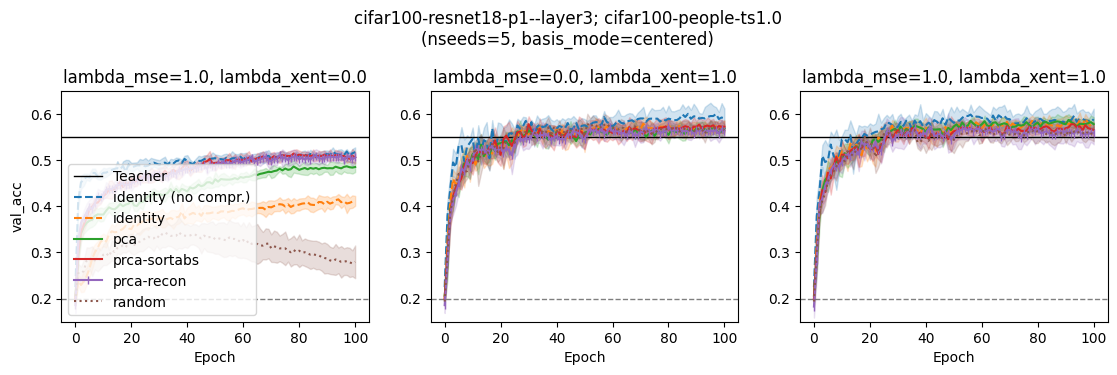

In [90]:
def viz(
    teacher_model, 
    dataset, 
    layer, 
    training_size, 
    main_compression_ratio,
    arr_lambda_mse_xent = [
        (1.0, 0.0),
        (0.0, 1.0),
        (1.0, 1.0)
    ],
    show_legend=True
):
    
    expected_nseeds=  5
    

    basis_mode = "centered"
    arr_bases = [
        ("identity", 1.0),
        ("identity", main_compression_ratio),
        ("pca", main_compression_ratio),
        ("prca-sortabs", main_compression_ratio),  
        ("prca-recon", main_compression_ratio),  
        ("random", main_compression_ratio)
    ]
    
    ncols = len(arr_lambda_mse_xent)
    
    plt.figure(figsize=(4.5*ncols, 3))
    
    plt.suptitle("\n".join([
      f"{teacher_model}--{layer}; {dataset}-ts{training_size}",
      f"(nseeds={expected_nseeds}, basis_mode={basis_mode})"
    ]), y=1.15)
    
    
    teacher_acc, _ = get_accuracy(teacher_model, dataset)
    
    vmax = teacher_acc + 0.1
    vmin = 0.15
    
    for idx, (lambda_mse, lambda_xent) in enumerate(arr_lambda_mse_xent):
        plt.subplot(1, ncols, idx+1)
        plt.axhline(teacher_acc, ls="-", color="black", lw=1, label="Teacher")       
        plt.axhline(0.2, ls="--", color="black", alpha=0.5, lw=1)

        
        plt.title(f"lambda_mse={lambda_mse}, lambda_xent={lambda_xent}")

        for basis_name, compression_ratio in arr_bases:
            df = read_data(
                dataset=dataset,
                teacher_model=teacher_model,
                layer=layer,
                lambda_mse=lambda_mse,
                lambda_xent=lambda_xent,
                basis_name=f"{basis_name}--{basis_mode}",
                compression_ratio=compression_ratio,
                training_size=training_size
            )
            
            np.testing.assert_allclose(df["val_acc"]["count"], expected_nseeds)

            epochs = df["epoch"]
            mean = df["val_acc"]["mean"]
            std = df["val_acc"]["std"]
            
            plt.plot(
                epochs,
                mean,
                label=label(basis_name, compression_ratio),                
                ls=ls(basis_name),
                marker=marker(basis_name)
            )
            
            plt.fill_between(
                epochs,
                mean-std,
                mean+std,
                color=plt.gca().lines[-1].get_color(),
                alpha=0.2
            )
            
            plt.xlabel("Epoch")
            plt.ylim([vmin, vmax])
            
            
        if idx == 0:
            plt.ylabel("val_acc")
            
            if show_legend:
                plt.legend(loc="lower left")
        
viz(
    training_size=1.0, 
    main_compression_ratio=8,
    teacher_model="cifar100-resnet18-p1",
    layer="layer3",
    dataset="cifar100-people",
)

# Comparision of MSE Distillation Across Different Trianing Sizes

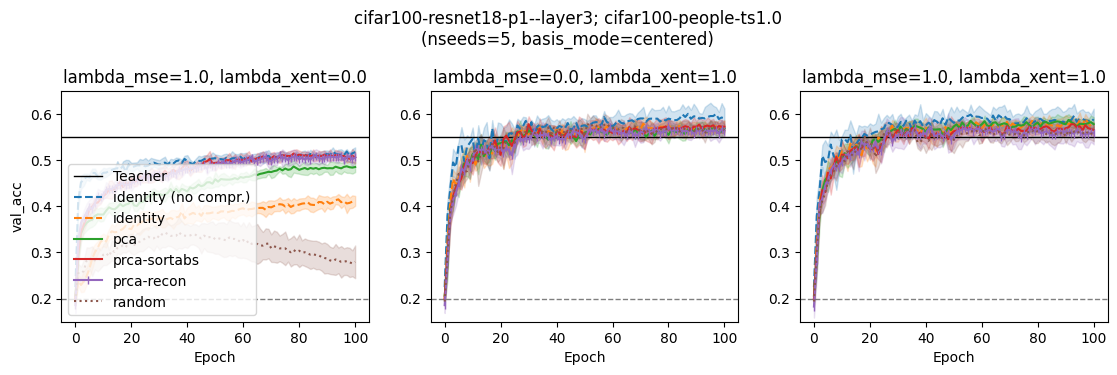

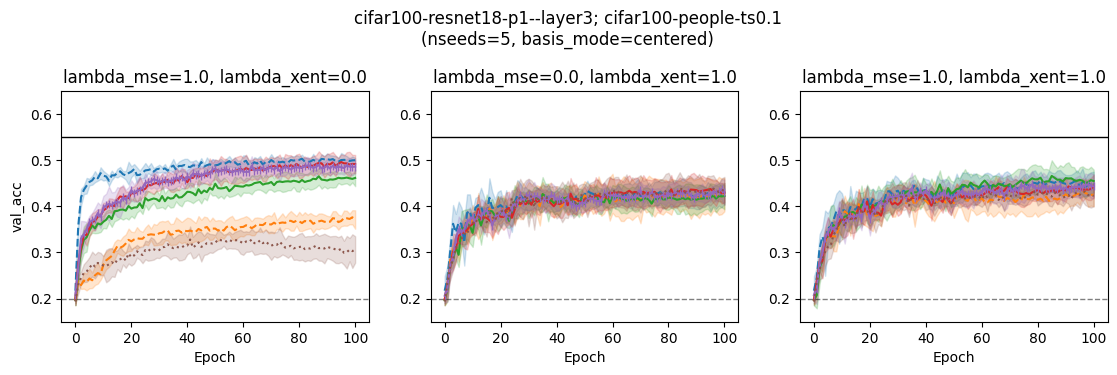

In [91]:
for ix, training_size in enumerate([1.0,0.1]):
    viz(
        training_size=training_size, 
        main_compression_ratio=8,
        teacher_model="cifar100-resnet18-p1",
        layer="layer3",
        dataset="cifar100-people",
        show_legend=ix==0
    )

# Summary (to be confirmed)

Aims:
1. Verify that distilation can achieve good performance (as in the accuracy basis curve)
2. Influence of `MSE` and `Xent` terms on distillation.


Conclusions
1. Yes, the training configuration leads to expected performance. 
2. In small training size, using only MSE performs better than using Xent alone. Here, *using the two objectves together does NOT seem to slightly better overall results.* One explanation to this could be that we have to adjust the ratio (right now it is $\alpha=0.5$) in order to see the improvement.